In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, LogNorm
from metpy.plots import ctables
import matplotlib as mpl
from matplotlib import rcParams
from datetime import datetime

#### Plot settings:
rcParams['font.family'] = 'serif'
rcParams['mathtext.fontset'] = 'cm'
rcParams['mathtext.rm'] = 'serif'
mpl.rcParams["figure.dpi"] = 350
today = datetime.today().strftime("%Y-%m-%d")


### Define necessary functions: 

In [2]:
def dmean(var):
    """Domain mean: average over time, y, x."""
    return np.nanmean(var, axis=(0, 2, 3))

def compute_ice_profiles(datasets, ice_vars):
    """Return domain-mean profiles and total ice for each dataset."""
    out = {}
    for label, ds in datasets.items():
        species = {v: dmean(ds.variables[v][:]) for v in ice_vars}
        species['qt'] = sum(species.values())
        out[label] = species
    return out

def compute_hydrometeor_profiles(datasets, micro_vars):
    """Return domain-mean profiles and total microphysical species for each dataset."""
    out = {}
    for label, ds in datasets.items():
        species = {v: dmean(ds.variables[v][:]) for v in hydro_vars}
        species['qth'] = sum(species.values())
        out[label] = species
    return out

### Load in the files: 

In [3]:
path = '/glade/u/home/mfranke/work/CM1/casper/derecho_comp/cm1r21.1/cm1.runs/Simulations/'
version = 'v455'

### Set the variables:
ice_vars = ['qi', 'qs', 'qg']     ## in kg/kg
hydro_vars = ['qi', 'qs', 'qg', 'qc', 'qr']
scale_gkg = 1000   ## Use this to scale mixing ratios from kg/kg to g/kg

### Open the files:
ctrl = xr.open_dataset(path + f'cm1out_ctrl_{version}_1600.nc', decode_timedelta = True).isel(time = slice(0,81))[hydro_vars]
lens = xr.open_dataset(path + f'cm1out_lens_{version}_1600.nc', decode_timedelta = True).isel(time = slice(0,81))[hydro_vars]
crh = xr.open_dataset(path + f'cm1out_lens_{version}_1600_constantRH_20hrs.nc', decode_timedelta = True)[hydro_vars]

### Put into a dictionary for easy calculations: 
datasets = {
    'CTRL':    ctrl,
    'LENS2':   lens,
    'CRH': crh}

### Set the dimensions:
time_minutes = ctrl.time / np.timedelta64(1,'m')
time_hours = ctrl.time / np.timedelta64(1,'h')
z = ctrl.zh     ## in km


### Apply the functions and compute:

In [4]:
ice_profiles = compute_ice_profiles(datasets, ice_vars)
hydrometeor_profiles = compute_hydrometeor_profiles(datasets, hydro_vars)

### Plotting for Ice: 

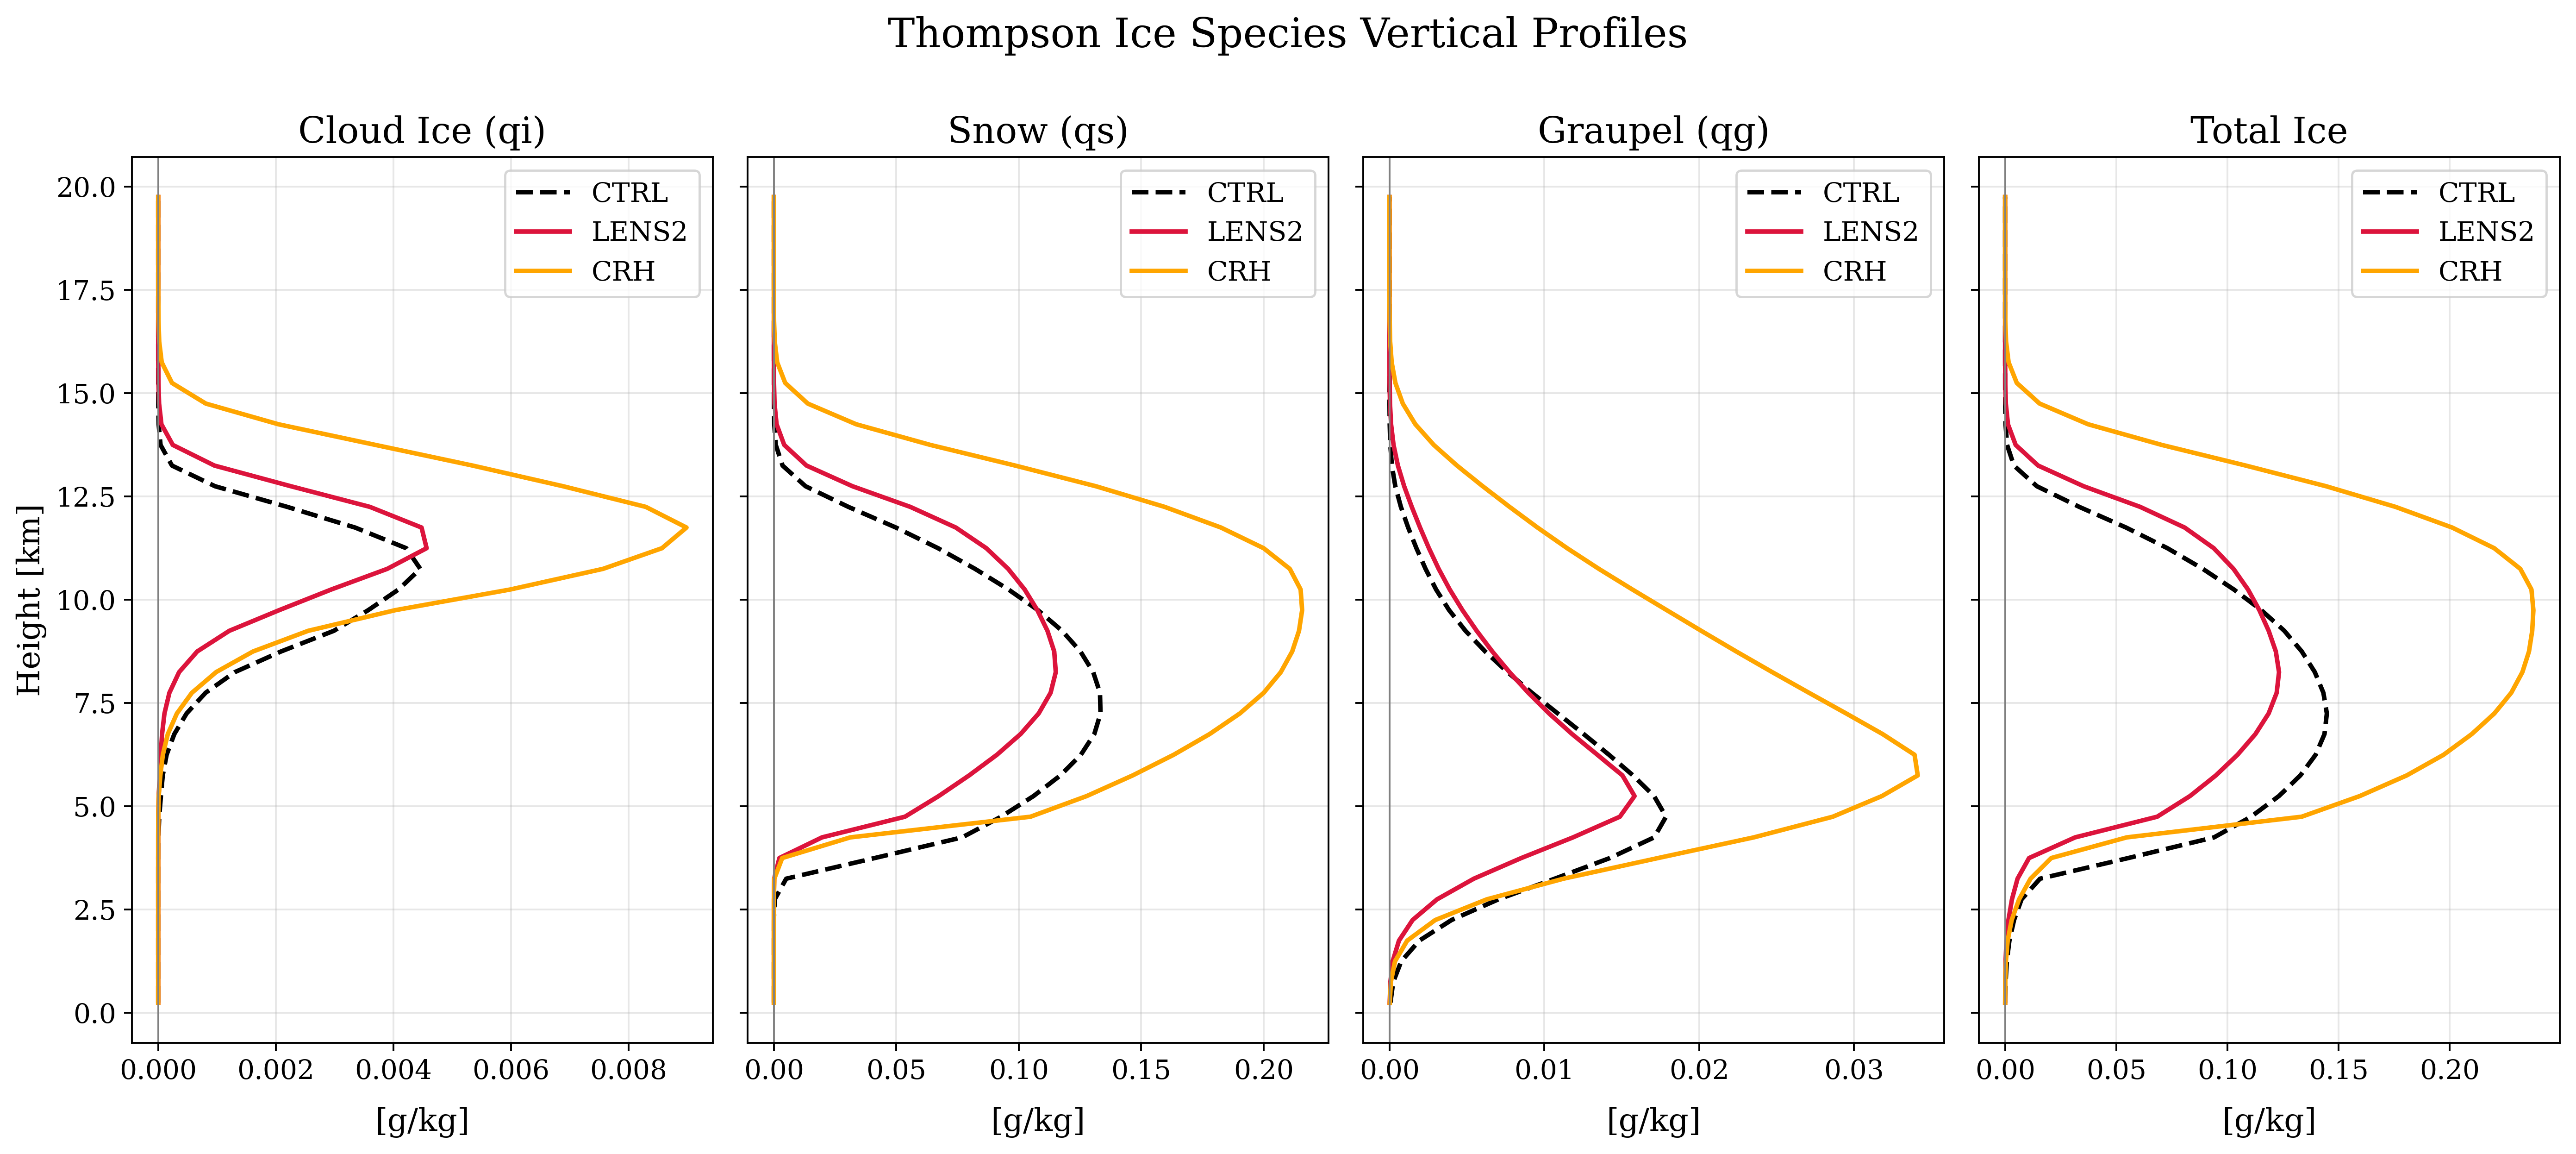

In [5]:
### Plot settings: 
var_keys = ['qi', 'qs', 'qg', 'qt']
titles   = ['Cloud Ice (qi)', 'Snow (qs)', 'Graupel (qg)', 'Total Ice']
colors = {'CTRL': 'black', 'LENS2': 'crimson', 'CRH': 'orange'}
linestyle = {'CTRL' : '--', 'LENS2' : '-', 'CRH' : '-'}

fs_legend = 12
fs_axislabel = 14
fs_maintitle = 18
fs_subplot = 16
fs_ticks = 12
##=================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)

for ax, var, title in zip(axes, var_keys, titles):
    for label, color in colors.items():
        ax.plot(ice_profiles[label][var] * scale_gkg, z,
                color=color, lw=2, ls=linestyle[label], label=f'{label}')
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_title(title, fontsize = fs_subplot)
    ax.set_xlabel('[g/kg]', fontsize = fs_axislabel, labelpad = 10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=fs_legend)
    ax.tick_params(axis='both', labelsize=fs_ticks)
    
axes[0].set_ylabel('Height [km]', fontsize = fs_axislabel)
plt.suptitle('Thompson Ice Species Vertical Profiles', fontsize=fs_maintitle, y = 1.01)
plt.tight_layout()

### Save figure: 
# plt.savefig('./Figures/thompson_ice_profiles.jpg', bbox_inches = 'tight')


### Plotting for all hydrometeors: 

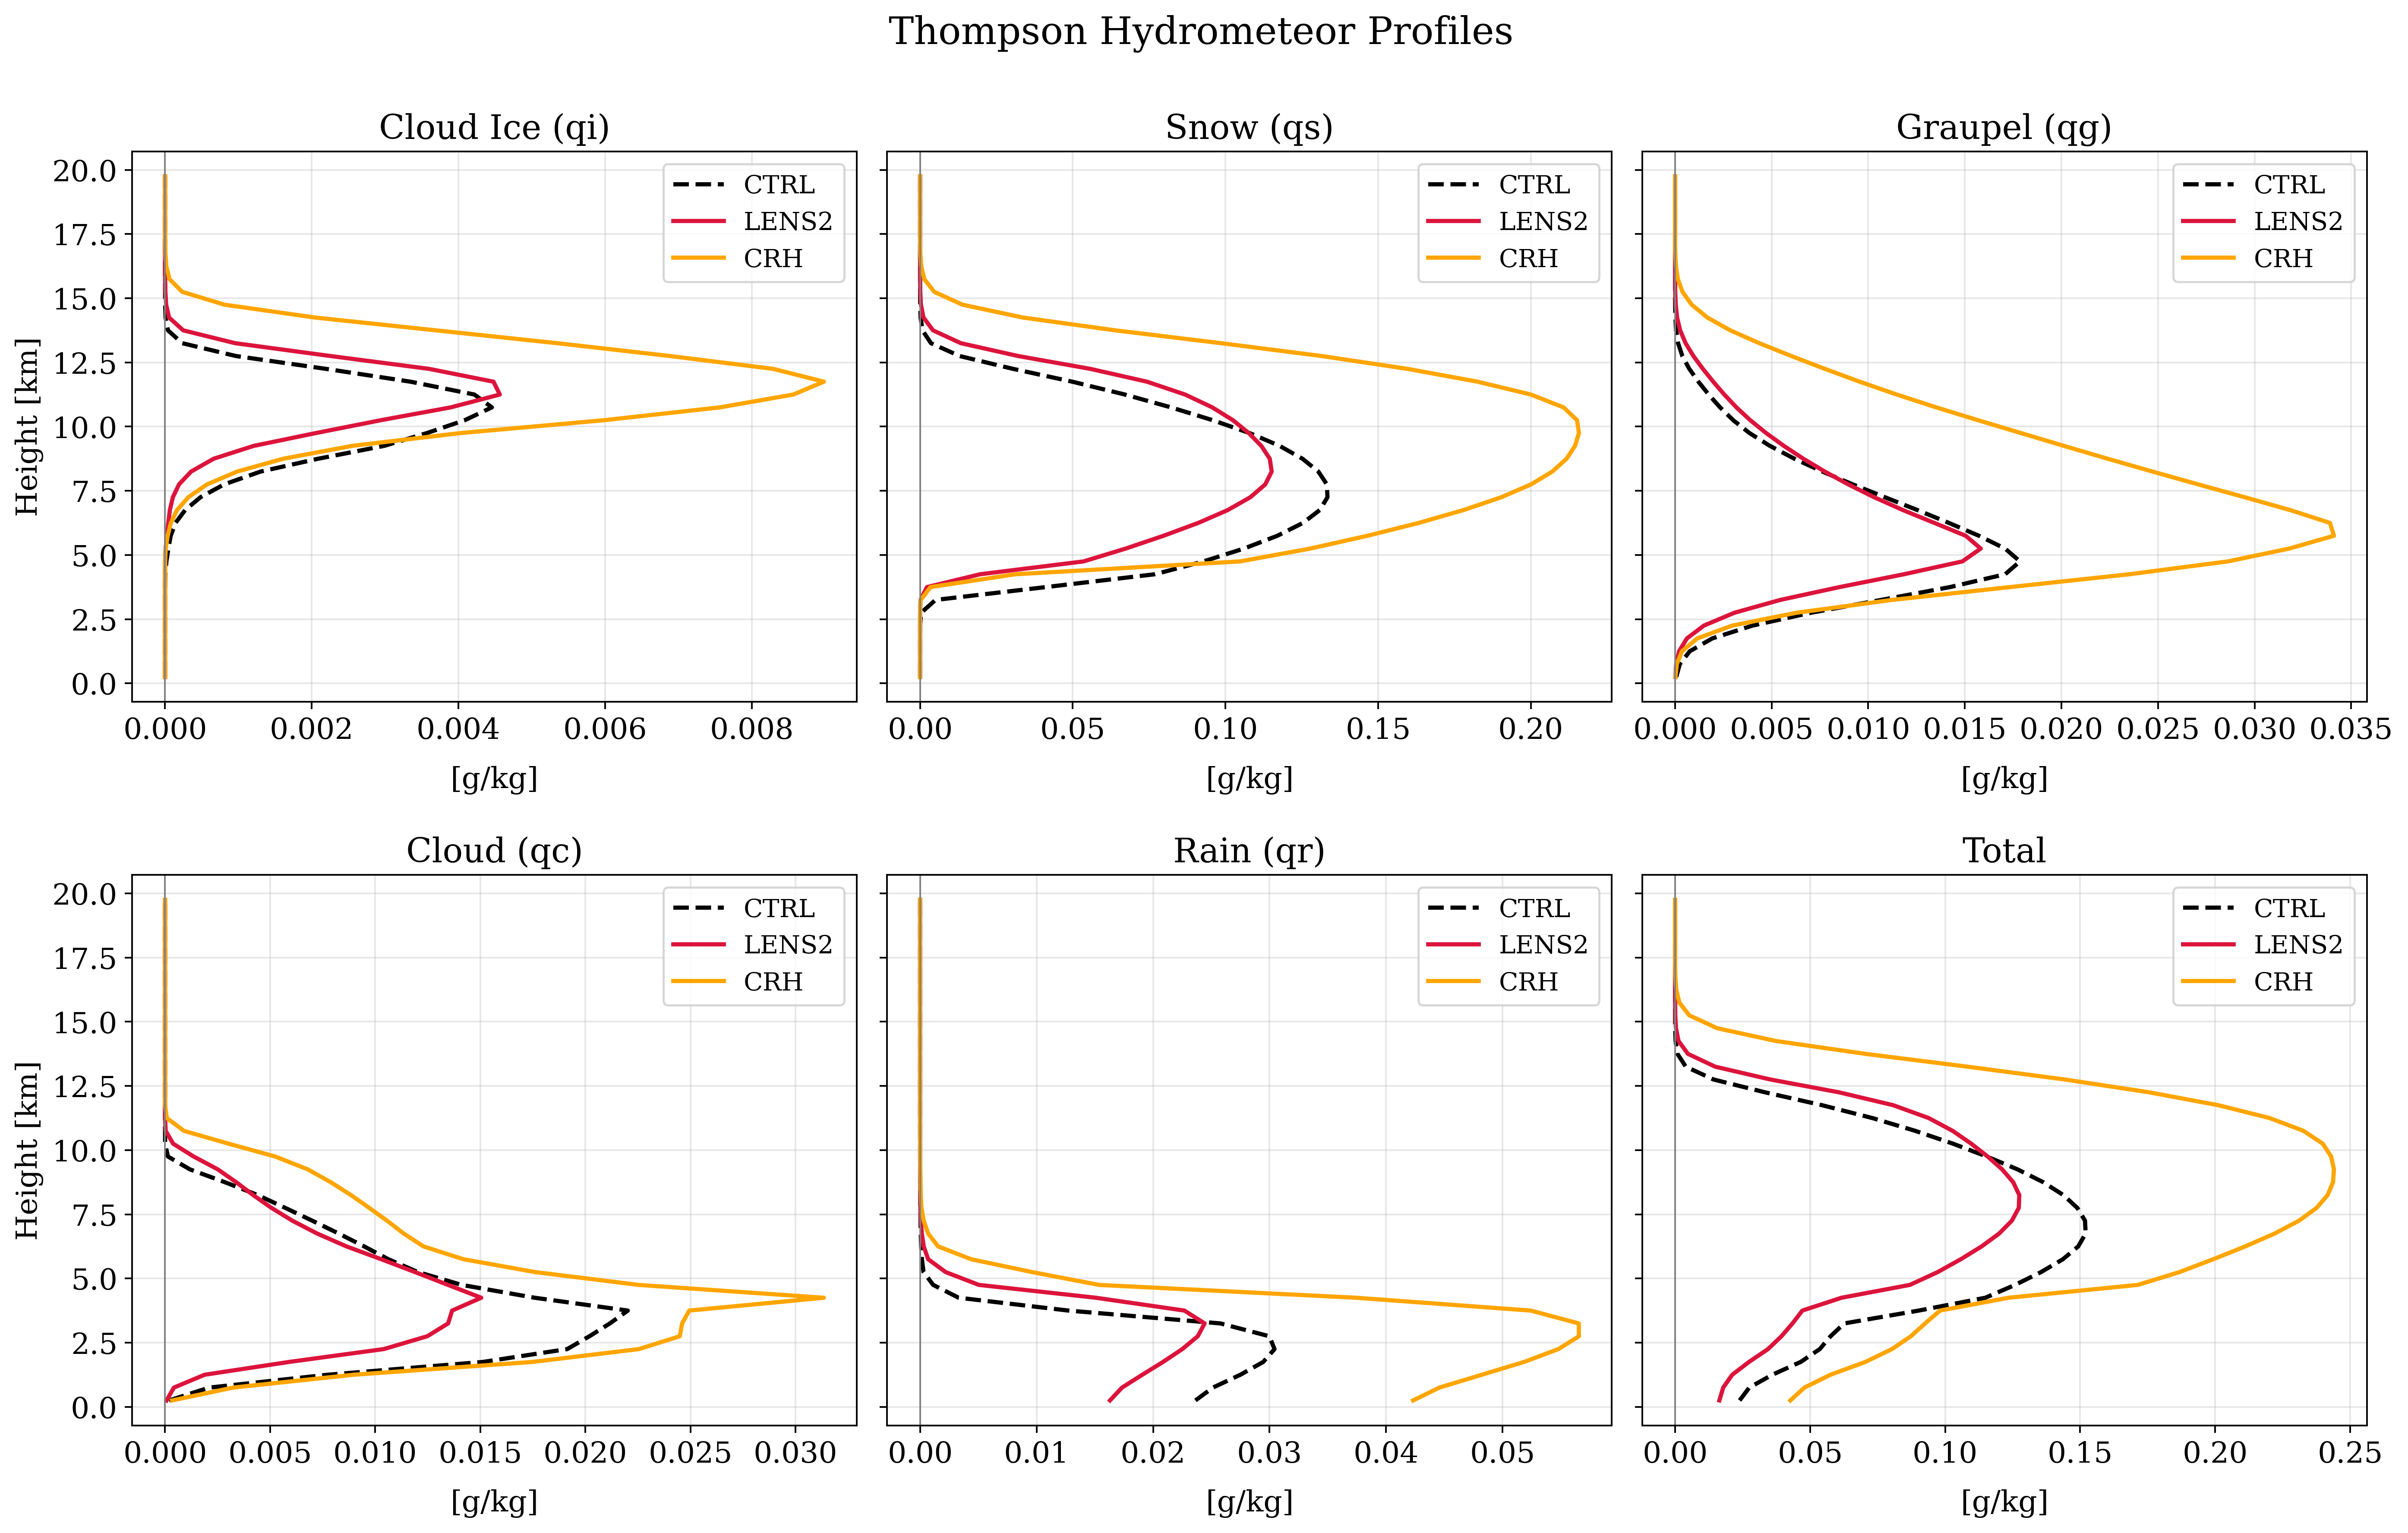

In [16]:
### Plot settings: 
var_keys = ['qi', 'qs', 'qg', 'qc', 'qr', 'qth']
titles   = ['Cloud Ice (qi)', 'Snow (qs)', 'Graupel (qg)', 'Cloud (qc)', 'Rain (qr)', 'Total']
colors = {'CTRL': 'black', 'LENS2': 'crimson', 'CRH': 'orange'}
linestyle = {'CTRL': '--', 'LENS2': '-', 'CRH': '-'}

fs_legend = 12
fs_axislabel = 14
fs_maintitle = 18
fs_subplot = 16
fs_ticks = 14
##=================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for ax, var, title in zip(axes.flatten(), var_keys, titles):
    for label, color in colors.items():
        ax.plot(hydrometeor_profiles[label][var] * scale_gkg, z,
                color=color, lw=2, ls=linestyle[label], label=f'{label}')
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_title(title, fontsize=fs_subplot)
    ax.set_xlabel('[g/kg]', fontsize=fs_axislabel, labelpad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=fs_legend)
    ax.tick_params(axis='both', labelsize=fs_ticks)

axes[0, 0].set_ylabel('Height [km]', fontsize=fs_axislabel)
axes[1, 0].set_ylabel('Height [km]', fontsize=fs_axislabel)
plt.suptitle('Thompson Hydrometeor Profiles', fontsize=fs_maintitle, y=1.01)
plt.tight_layout(h_pad = 2)

### Save figure: 
# plt.savefig('./Figures/thompson_hydrometeor_profiles.jpg', bbox_inches = 'tight')
